<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   프로젝트ID    1000 non-null   str           
 1   부서        1000 non-null   str           
 2   지역        1000 non-null   str           
 3   예산(백만원)   970 non-null    float64       
 4   집행액(백만원)  1000 non-null   int64         
 5   만족도       950 non-null    float64       
 6   민원건수      1000 non-null   int64         
 7   상태        1000 non-null   str           
 8   시작일       1000 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 70.4 KB
None


C:\Users\miran\AppData\Local\Temp\ipykernel_97716\3362585757.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_sat.values, y=dept_sat.index, ax=axes[0, 0], palette='Blues_r') # 가로 막대 그래프 그리기
C:\Users\miran\AppData\Local\Temp\ipykernel_97716\3362585757.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='상태', y='만족도', data=df, ax=axes[0, 1], palette='Set3') # 데이터의 중앙값과 편차 범위 표시


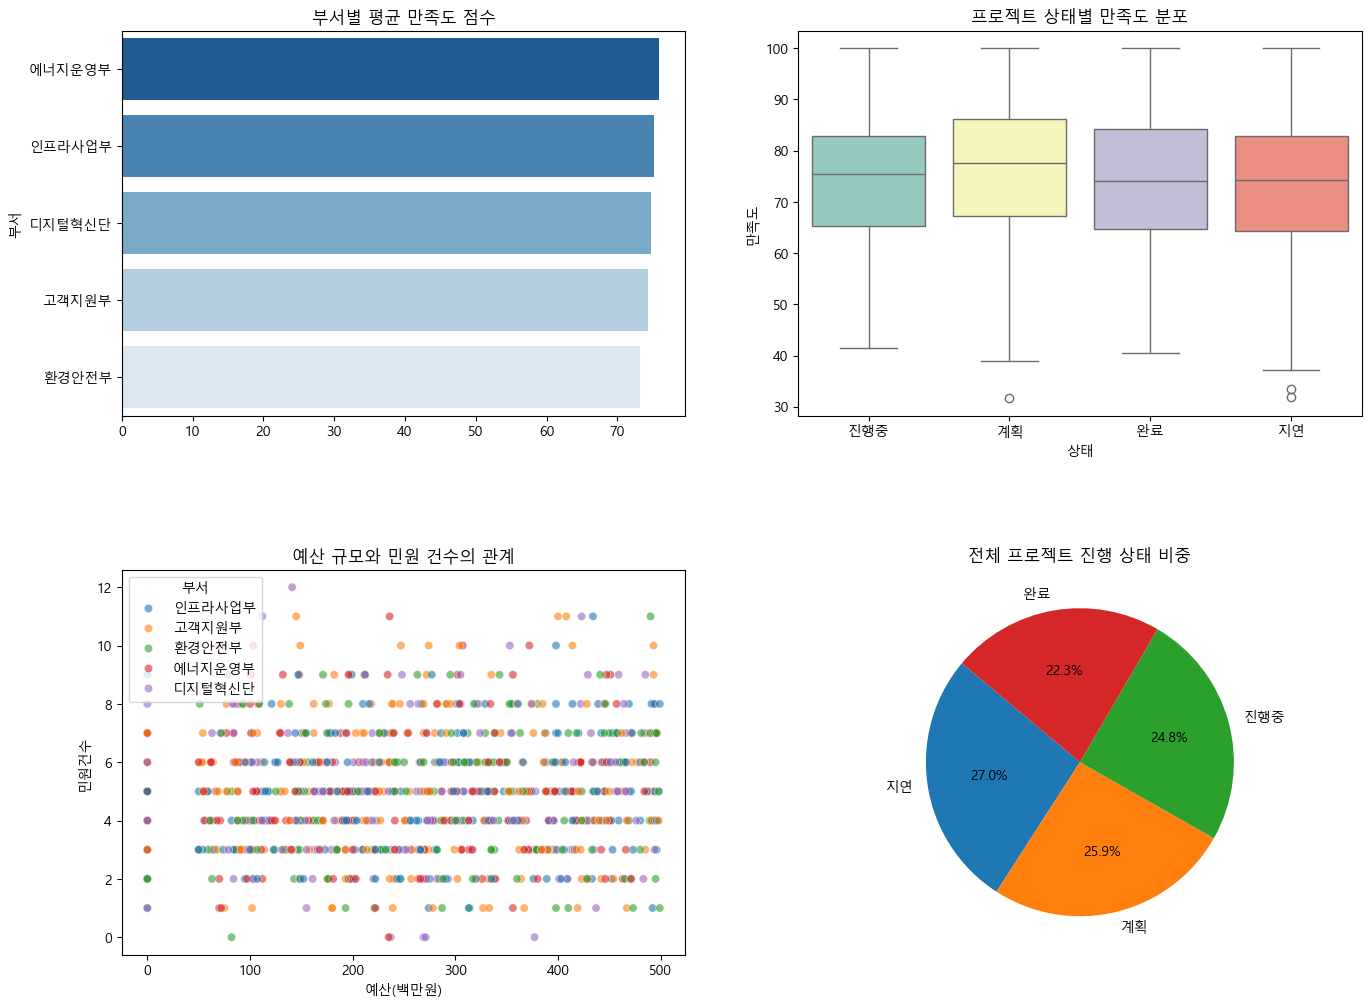

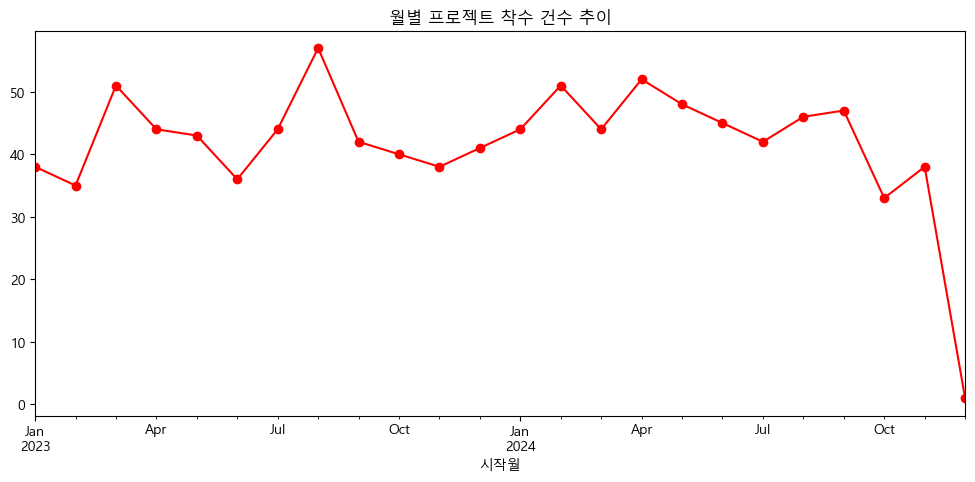

In [2]:
import pandas as pd                # 데이터 판다스(표) 처리 도구
import numpy as np                 # 수치 계산 및 결측치 생성 도구
import matplotlib.pyplot as plt    # 기본 그래프 그리기 도구
import seaborn as sns              # 세련된 통계 시각화 도구
from datetime import datetime      # 날짜 데이터 처리 도구

# --- 환경 설정 ---
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 깨짐 방지 (맑은 고딕)
plt.rcParams['axes.unicode_minus'] = False    # 그래프 수치 마이너스 기호 깨짐 방지

# --- 1. 데이터 불러오기 ---
df = pd.read_excel('public_business_data.xlsx') # 생성된 실무 엑셀 파일 읽기
print(df.info())                                # 데이터 구조 및 빈칸(결측치) 개수 확인

# --- 2. 데이터 전처리 (정제 작업) ---
df['만족도'] = df['만족도'].fillna(df['만족도'].mean()) # 만족도 빈칸을 전체 평균으로 채우기
df['예산(백만원)'] = df['예산(백만원)'].fillna(0)       # 예산 빈칸을 0으로 처리
df['집행률'] = (df['집행액(백만원)'] / df['예산(백만원)'] * 100).replace([np.inf, -np.inf], 0).fillna(0) # 집행률 계산 및 오류값 처리
df['시작월'] = df['시작일'].dt.to_period('M')          # '2024-03-28'을 '2024-03' 월 단위로 변경

# --- 3. 시각화 (보고서용 그래프) 🍋p384 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2행 2열(총 4개)의 그래프 틀 만들기
plt.subplots_adjust(hspace=0.4)                  # 그래프 간 위아래 간격 띄우기

# (1) 막대 그래프 (부서별 비교)
dept_sat = df.groupby('부서')['만족도'].mean().sort_values(ascending=False) # 부서별 만족도 평균 계산 및 🍋정렬
sns.barplot(x=dept_sat.values, y=dept_sat.index, ax=axes[0, 0], palette='Blues_r') # 가로 막대 그래프 그리기
axes[0, 0].set_title('부서별 평균 만족도 점수')   # 첫 번째 그래프 제목 설정

# (2) 박스 플롯 (상태별 분포/이상치)
sns.boxplot(x='상태', y='만족도', data=df, ax=axes[0, 1], palette='Set3') # 데이터의 중앙값과 편차 범위 표시
axes[0, 1].set_title('프로젝트 상태별 만족도 분포') # 두 번째 그래프 제목 설정

# (3) 산점도 (예산과 민원의 상관관계)
sns.scatterplot(x='예산(백만원)', y='민원건수', hue='부서', data=df, ax=axes[1, 0], alpha=0.6) # 점을 찍어 두 변수의 관계 표시
axes[1, 0].set_title('예산 규모와 민원 건수의 관계') # 세 번째 그래프 제목 설정

# (4) 파이 차트 (전체 비중)
status_counts = df['상태'].value_counts() # 각 상태별(완료, 지연 등) 개수 세기
axes[1, 1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140) # 원형 그래프 그리기
axes[1, 1].set_title('전체 프로젝트 진행 상태 비중') # 네 번째 그래프 제목 설정

plt.show() # 그려진 4개의 그래프 화면에 출력

# (5) 선 그래프 (시간에 따른 추이)
plt.figure(figsize=(12, 5))               # 새로운 단독 그래프 창 만들기
monthly_trends = df.groupby('시작월').size() # 월별 프로젝트 개수 합계 계산
monthly_trends.plot(kind='line', marker='o', color='red') # 점이 찍힌 선 그래프 그리기
plt.title('월별 프로젝트 착수 건수 추이')   # 그래프 제목 설정
plt.show()                                # 선 그래프 출력